In [3]:
print(data.columns.tolist())

['가입자일련번호', '시도코드', '성별코드', '연령대코드(5세단위)', '신장', '체중', '허리둘레', '수축기혈압', '이완기혈압', '식전혈당(공복혈당)', '총콜레스테롤', '트리글리세라이드', 'HDL콜레스테롤', 'LDL콜레스테롤', '혈색소', '요단백', '혈청크레아티닌', '혈청지오티(AST)', '혈청지피티(ALT)', '감마지티피', '흡연상태', '음주여부', '당뇨여부', 'BMI', 'TG_HDL']


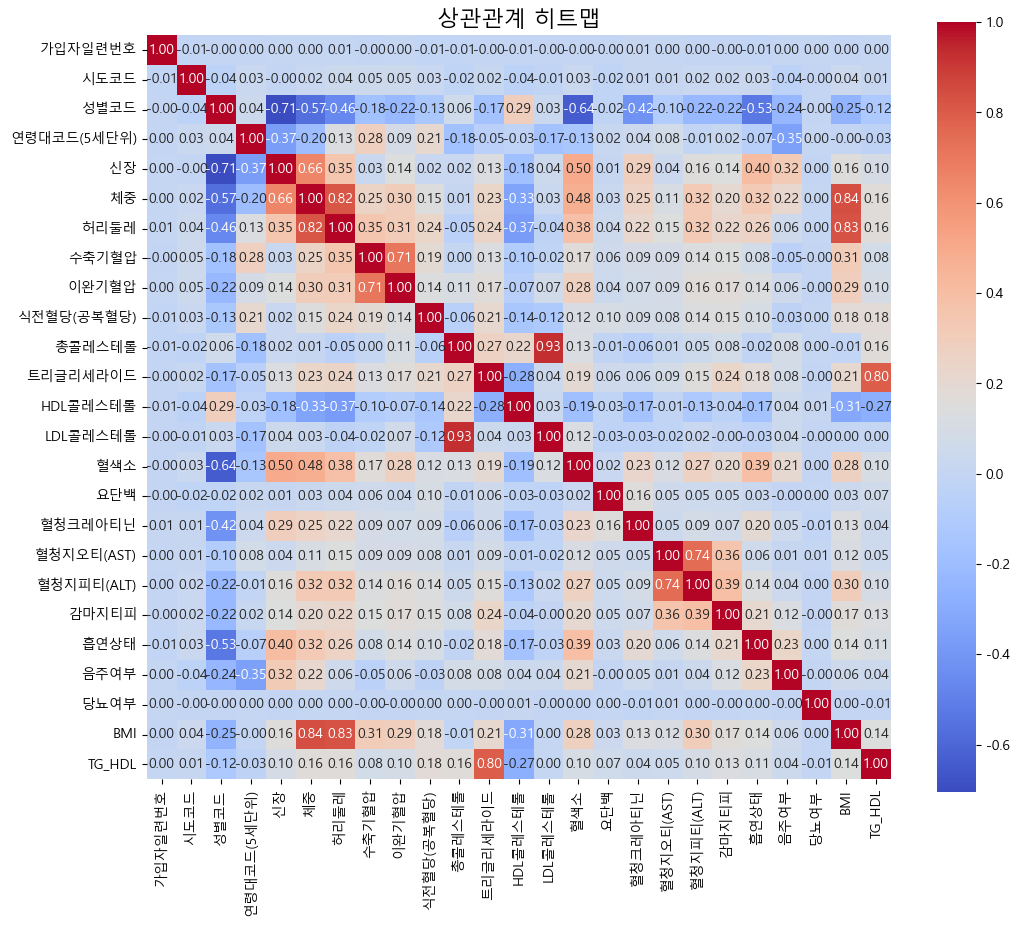

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import numpy as np

# 한글 폰트 설정 (Windows: Malgun Gothic, Mac: AppleGothic, Linux: NanumGothic 등)
plt.rc('font', family='Malgun Gothic')  # 윈도우용
plt.rc('axes', unicode_minus=False)     # 마이너스 깨짐 방지

# 수치형 변수만 선택
numeric_cols = data.select_dtypes(include=[np.number])

# 상관계수 계산
corr = numeric_cols.corr()

# 히트맵 시각화
plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar=True)

plt.title("상관관계 히트맵", fontsize=16)
plt.show()


In [25]:
# 예시: 공복혈당 126 이상이면 당뇨 (WHO 기준)
df['당뇨여부'] = (df['식전혈당(공복혈당)'] >= 126).astype(int)


In [26]:
# 예시: 공복혈당 126 이상이면 당뇨 (WHO 기준)
df['당뇨여부'] = (df['식전혈당(공복혈당)'] >= 126).astype(int)


In [27]:
# 상관계수 구하기 (라벨과만)
corrs = df.corr(numeric_only=True)['당뇨여부'].drop('당뇨여부')

# 절대값 기준 상위 10개 변수 선택
top10 = corrs.abs().sort_values(ascending=False).head(10).index.tolist()
print("Top10 변수:", top10)


Top10 변수: ['식전혈당(공복혈당)', '허리둘레', '연령대코드(5세단위)', 'LDL콜레스테롤', '수축기혈압', 'HDL콜레스테롤', '트리글리세라이드', '감마지티피', '총콜레스테롤', '요단백']


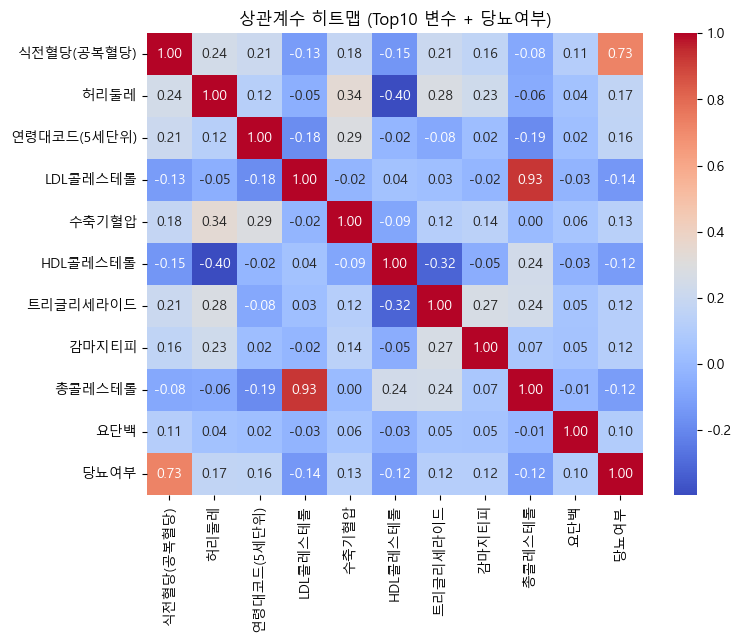

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import numpy as np

# 한글 폰트 설정 (Windows: Malgun Gothic, Mac: AppleGothic, Linux: NanumGothic 등)
plt.rc('font', family='Malgun Gothic')  # 윈도우용
plt.rc('axes', unicode_minus=False)     # 마이너스 깨짐 방지

plt.figure(figsize=(8,6))
sns.heatmap(df[top10 + ['당뇨여부']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("상관계수 히트맵 (Top10 변수 + 당뇨여부)")
plt.show()


In [37]:
import pandas as pd
import cx_Oracle

# Oracle 연결
dsn = cx_Oracle.makedsn("localhost", 1521, sid="orcl")
conn = cx_Oracle.connect(user="mingk", password="1234", dsn=dsn)

# 건강검진 데이터
query_health = "SELECT * FROM 건강검진"
health_df = pd.read_sql(query_health, conn)

# 진료내역 데이터 (부상병코드까지 포함)
query_claims = """
SELECT 가입자일련번호, 주상병코드, 부상병코드
FROM 진료내역
"""
claims_df = pd.read_sql(query_claims, conn)

conn.close()

print("건강검진 데이터 컬럼:", health_df.columns.tolist())
print("진료내역 데이터 컬럼:", claims_df.columns.tolist())


건강검진 데이터 컬럼: ['가입자일련번호', '시도코드', '성별코드', '연령대코드', '신장', '체중', '허리둘레', '수축기혈압', '이완기혈압', '식전혈당', '총콜레스테롤', '트리글리세라이드', 'HDL콜레스테롤', 'LDL콜레스테롤', '혈색소', '요단백', '혈청크레아티닌', '혈청지오티', '혈청지피티', '감마지티피', '흡연상태', '음주여부']
진료내역 데이터 컬럼: ['가입자일련번호', '주상병코드', '부상병코드']


In [ ]:
# ============================
# 라이브러리 불러오기
# ============================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, precision_recall_curve

# IterativeImputer는 실험적 기능 → enable 먼저 import 필요
from sklearn.experimental import enable_iterative_imputer  
from sklearn.impute import IterativeImputer

from imblearn.combine import SMOTETomek

from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import StackingClassifier

# ============================
# 1. 데이터 불러오기
# ============================
df = pd.read_csv("건강검진_진료내역_공통가입자2023.csv",
                 dtype={'가입자일련번호': str})

df["당뇨여부"] = (
    df["주상병코드"].astype(str).str.startswith("E1") |
    df["부상병코드"].astype(str).str.startswith("E1")
).astype(int)

print("라벨 분포:\n", df["당뇨여부"].value_counts())
features = [
    "허리둘레", "수축기혈압", "식전혈당(공복혈당)",
    "총콜레스테롤", "연령대코드(5세단위)", "성별코드_health",
    "체중", "신장", "이완기혈압",
    "트리글리세라이드", "HDL콜레스테롤", "LDL콜레스테롤"
]

X = df[features].copy()
y = df["당뇨여부"]

X["BMI"] = df["체중"] / ((df["신장"]/100) ** 2)
X["맥압"] = df["수축기혈압"] - df["이완기혈압"]
X["TG_HDL"] = df["트리글리세라이드"] / (df["HDL콜레스테롤"] + 1e-5)
X["LDL_HDL"] = df["LDL콜레스테롤"] / (df["HDL콜레스테롤"] + 1e-5)

# ============================
# 3. 결측치 처리
# ============================
imputer = IterativeImputer(random_state=42)
X_imputed = imputer.fit_transform(X)
X = pd.DataFrame(X_imputed, columns=X.columns)

# ============================
# 4. Train/Test Split
# ============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ============================
# 5. Resampling (SMOTETomek)
# ============================
smt = SMOTETomek(random_state=42)
X_res, y_res = smt.fit_resample(X_train, y_train)

print("Before Resample:", y_train.value_counts().to_dict())
print("After Resample:", y_res.value_counts().to_dict())

# ============================
# 6. Base Models
# ============================
cat = CatBoostClassifier(
    iterations=800, depth=8, learning_rate=0.03,
    class_weights=[1, 15], verbose=0, random_seed=42
)

lgb = LGBMClassifier(
    n_estimators=800, max_depth=8, learning_rate=0.03,
    class_weight={0:1, 1:15}, random_state=42
)

xgb = XGBClassifier(
    n_estimators=800, max_depth=8, learning_rate=0.03,
    scale_pos_weight=15, random_state=42,
    use_label_encoder=False, eval_metric="logloss"
)

# ============================
# 7. Stacking Ensemble
# ============================
estimators = [
    ('cat', cat),
    ('lgb', lgb),
    ('xgb', xgb)
]

stack = StackingClassifier(
    estimators=estimators,
    final_estimator=CatBoostClassifier(
        iterations=500, depth=6, learning_rate=0.05,
        class_weights=[1, 10], verbose=0, random_seed=42
    ),
    cv=5, n_jobs=-1
)

stack.fit(X_res, y_res)

# ============================
# 8. 예측 및 Threshold 최적화
# ============================
y_proba = stack.predict_proba(X_test)[:, 1]

# Precision-Recall 커브
prec, rec, thresholds = precision_recall_curve(y_test, y_proba)
f1_scores = 2 * prec * rec / (prec + rec + 1e-6)

# Precision·Recall·F1 평균을 최대로 하는 Threshold
score_custom = (prec + rec + f1_scores) / 3
best_idx = np.argmax(score_custom)
best_threshold = thresholds[best_idx]

y_pred_best = (y_proba >= best_threshold).astype(int)

print(f"\n최적 Threshold: {best_threshold:.3f}")
print(classification_report(y_test, y_pred_best))


라벨 분포:
 당뇨여부
0    180693
1     30403
Name: count, dtype: int64
Before Resample: {0: 144554, 1: 24322}
After Resample: {0: 144534, 1: 144534}

최적 Threshold: 0.955
              precision    recall  f1-score   support

           0       0.96      0.95      0.95     36139
           1       0.70      0.76      0.73      6081

    accuracy                           0.92     42220
   macro avg       0.83      0.85      0.84     42220
weighted avg       0.92      0.92      0.92     42220



In [4]:
import pandas as pd

# 전체 데이터 분포
total_counts = y.value_counts().to_dict()

# 학습 데이터 (Before resample) 분포
before_counts = y_train.value_counts().to_dict()

# 학습 데이터 (After resample) 분포
after_counts = y_res.value_counts().to_dict()

# 표 생성
table = pd.DataFrame({
    "데이터 구분": ["원본 데이터", "이전 데이터", "샘플링 후 데이터"],
    "비당뇨(0)": [total_counts.get(0, 0), before_counts.get(0, 0), after_counts.get(0, 0)],
    "당뇨(1)": [total_counts.get(1, 0), before_counts.get(1, 0), after_counts.get(1, 0)],
})

# 비율 컬럼 추가
table["비율"] = table["비당뇨(0)"].astype(str) + " : " + table["당뇨(1)"].astype(str)

print(table)


      데이터 구분  비당뇨(0)   당뇨(1)               비율
0     원본 데이터  180693   30403   180693 : 30403
1     이전 데이터  144554   24322   144554 : 24322
2  샘플링 후 데이터  144534  144534  144534 : 144534
